# IMPORTS

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import ast
from tqdm import tqdm
from scipy.signal import find_peaks
from scipy.signal import savgol_filter

# DATA RETRIEVAL

In [2]:
BASE_DIR = "dataset/"
MODEL_DIR = "models/"
LEFT_HAND_DIR = os.path.join(BASE_DIR, "left")
RIGHT_HAND_DIR = os.path.join(BASE_DIR, "right")
#UPDRS_DIR = os.path.join(BASE_DIR, "csv")
UPDRS_FILE = os.path.join(BASE_DIR, "updrs_scores.csv")

In [3]:
#Load UPDRS Scores
updrs_df = pd.read_csv(UPDRS_FILE)
updrs_df.head()

,patient,updrs_right,updrs_left
0,PD0,1,1
1,PD1,3,3
2,PD2,1,1
3,PD3,3,3
4,PD4,2,2


In [4]:
#Helper Function to Read Signal Files
def read_signal_file(file_path):
    with open(file_path, "r") as f:
        values = [float(line.strip()) for line in f if line.strip()]
    return values

# DATA WRANGLING

 LEFT HAND DATA PREPARATION

In [5]:
#Process Left Hand Data
left_records = []

for patient_folder in os.listdir(LEFT_HAND_DIR):
    patient_path = os.path.join(LEFT_HAND_DIR, patient_folder)
    # print(patient_path)

    if not os.path.isdir(patient_path):
        continue

    patient_id = patient_folder

    file_text_path = os.path.join(patient_path, "Text files")
    amplitude_path = os.path.join(file_text_path, "Amplitude.txt")
    time_path = os.path.join(file_text_path, "Time.txt")

    if not os.path.exists(amplitude_path) or not os.path.exists(time_path):
        continue

    amplitude_values = read_signal_file(amplitude_path)
    time_values = read_signal_file(time_path)

    updrs_value = updrs_df.loc[
        updrs_df["patient"] == patient_id, "updrs_left"
    ].values

    # if len(updrs_value) == 0:
    #     continue

    updrs_value = updrs_value[0]

    left_records.append({
        "patient_id": patient_id,
        "updrs_left": updrs_value,
        "amplitude": amplitude_values,
        "time": time_values
    })


In [6]:
#Create Left Hand DataFrame, Pad to 1800 values and Save CSV
left_df = pd.DataFrame(left_records)

# Create target column: 1 = Parkinson's, 0 = Healthy
left_df["target"] = left_df["patient_id"].apply(lambda x: 1 if x.startswith("PD") else 0)

TARGET_LEN = 1800

def pad_signal(amplitude, time, target_len=TARGET_LEN):

    amplitude = np.array(amplitude, dtype=float)
    time = np.array(time, dtype=float)

    # Pad amplitude with its mean
    if len(amplitude) < target_len:
        pad_width = target_len - len(amplitude)
        amp_mean = np.mean(amplitude) if len(amplitude) > 0 else 0.0
        amplitude = np.pad( amplitude,(0, pad_width), mode='constant',
        constant_values=amp_mean
        )

    # Pad time with its mean
    if len(time) < target_len:
        pad_width = target_len - len(time)
        time_mean = np.mean(time) if len(time) > 0 else 0.0
        time = np.pad(
            time,
            (0, pad_width),
            mode='constant',
            constant_values=time_mean
        )

    return amplitude.tolist(), time.tolist()



# Apply to each row
for idx, row in left_df.iterrows():
    amplitude_padded, time_padded = pad_signal(row['amplitude'], row['time'])
    left_df.at[idx, 'amplitude'] = amplitude_padded
    left_df.at[idx, 'time'] = time_padded


left_csv_path = os.path.join(BASE_DIR, "processed/left.csv")

left_df.to_csv(left_csv_path, index=False)

In [7]:
# Check first row
first_row = left_df.iloc[0]

amplitude_len = len(first_row['amplitude'])
time_len = len(first_row['time'])

print(f"First row amplitude length: {amplitude_len}")
print(f"First row time length: {time_len}")



First row amplitude length: 1800
First row time length: 1800


LEFT HAND EXPLORATORY DATA ANALYSIS.

In [8]:
#Basic Statistics
left_df.head()

,patient_id,updrs_left,amplitude,time,target
0,C34,2,"[0.851907050083096, 0.8627108573966841, 0.8671...","[0.016666666666666666, 0.03333333333333333, 0....",0
1,C35,1,"[0.7659240331883278, 0.8466510181877207, 0.883...","[0.03333333333333333, 0.05, 0.0666666666666666...",0
2,C36,2,"[0.8699220059481613, 0.8954643663407749, 0.915...","[0.03333333333333333, 0.05, 0.0666666666666666...",0
3,C37,1,"[0.24363131117259645, 0.29041362353638617, 0.2...","[0.03333333333333333, 0.05, 0.0666666666666666...",0
4,C38,1,"[0.9413529091833805, 0.9603714679224232, 0.968...","[0.13333333333333333, 0.15, 0.1666666666666666...",0


In [9]:
left_df.describe()

,updrs_left,target
count,66.000000,66.000000
mean,1.924242,0.924242
std,0.949666,0.266638
min,0.000000,0.000000
25%,1.000000,1.000000
50%,2.000000,1.000000
75%,3.000000,1.000000
max,4.000000,1.000000


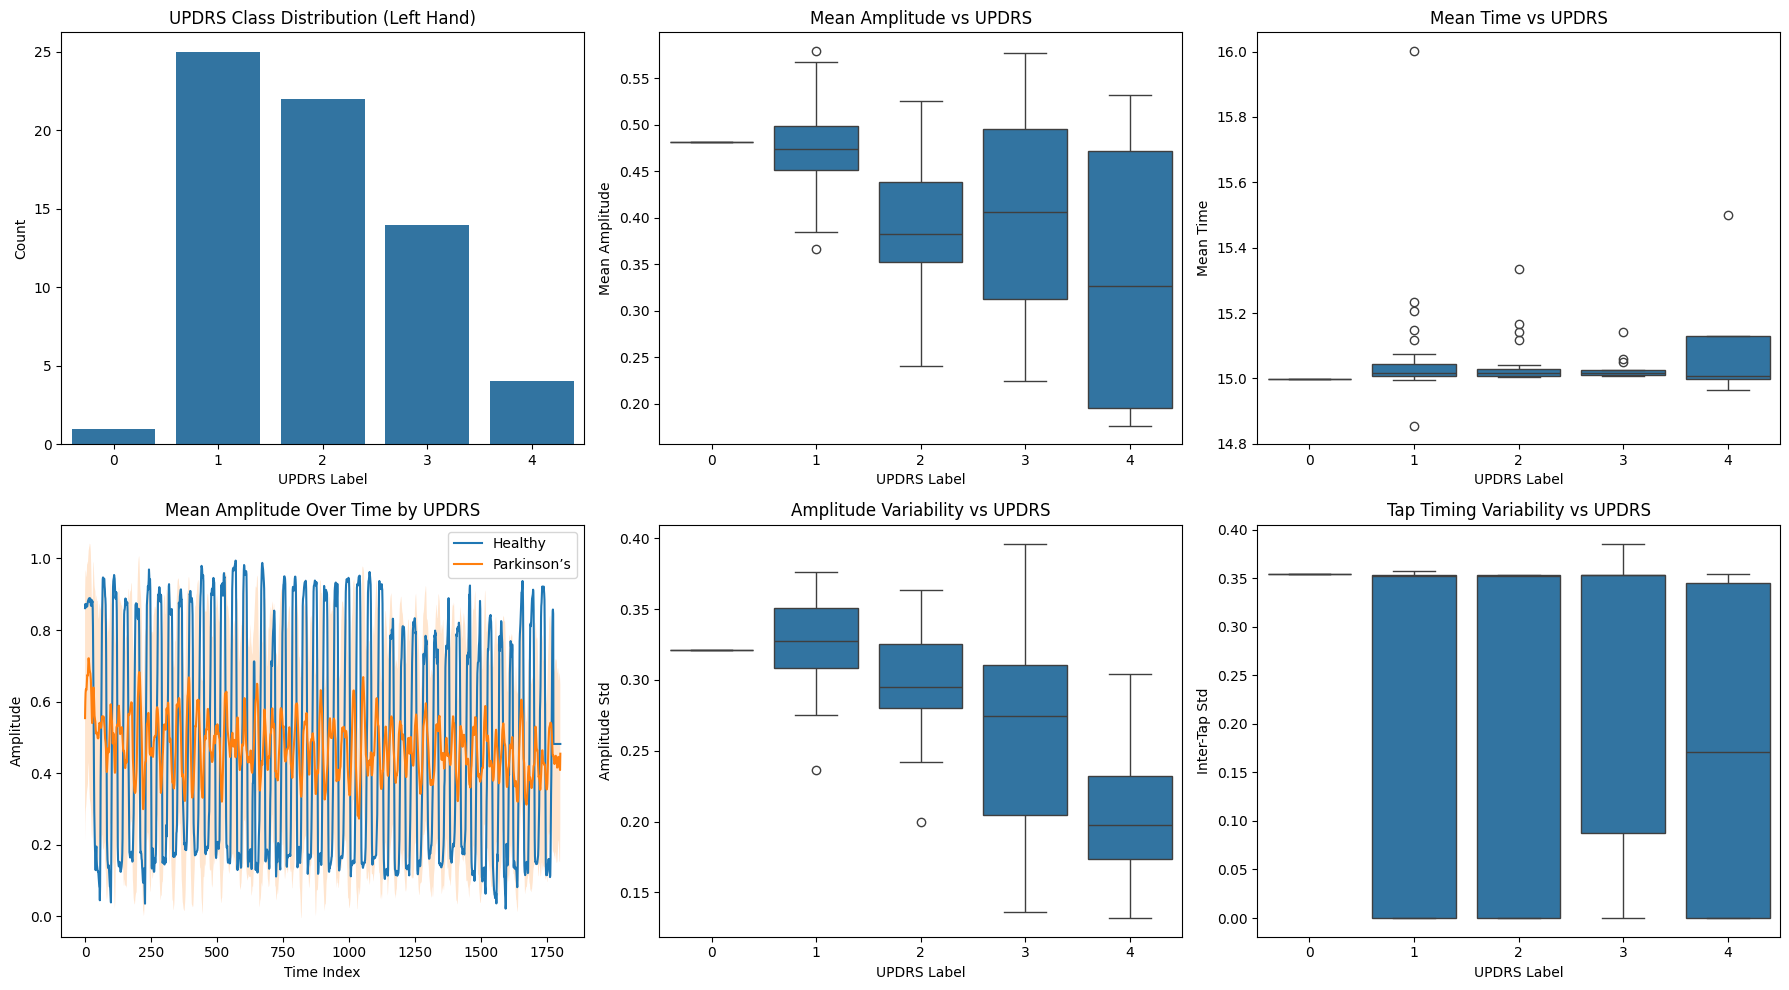

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# -------------------------------
# 1. UPDRS Class Distribution
# -------------------------------
sns.countplot(x="updrs_left", data=left_df, ax=ax[0, 0])
ax[0, 0].set_title("UPDRS Class Distribution (Left Hand)")
ax[0, 0].set_xlabel("UPDRS Label")
ax[0, 0].set_ylabel("Count")

# -------------------------------
# 2. Mean Amplitude vs UPDRS
# -------------------------------
left_amp_means = left_df["amplitude"].apply(np.mean)
sns.boxplot(x=left_df["updrs_left"], y=left_amp_means, ax=ax[0, 1])
ax[0, 1].set_title("Mean Amplitude vs UPDRS")
ax[0, 1].set_xlabel("UPDRS Label")
ax[0, 1].set_ylabel("Mean Amplitude")

# -------------------------------
# 3. Mean Time vs UPDRS
# -------------------------------
left_time_means = left_df["time"].apply(np.mean)
sns.boxplot(x=left_df["updrs_left"], y=left_time_means, ax=ax[0, 2])
ax[0, 2].set_title("Mean Time vs UPDRS")
ax[0, 2].set_xlabel("UPDRS Label")
ax[0, 2].set_ylabel("Mean Time")

# -------------------------------
# 4. Amplitude over Time by UPDRS
# -------------------------------
amp_0 = np.stack(left_df[left_df["updrs_left"] == 0]["amplitude"].values)
amp_1 = np.stack(left_df[left_df["updrs_left"] == 1]["amplitude"].values)

mean_0, std_0 = amp_0.mean(axis=0), amp_0.std(axis=0)
mean_1, std_1 = amp_1.mean(axis=0), amp_1.std(axis=0)

time_axis = np.arange(len(mean_0))

ax[1, 0].plot(time_axis, mean_0, label="Healthy")
ax[1, 0].fill_between(time_axis, mean_0-std_0, mean_0+std_0, alpha=0.2)

ax[1, 0].plot(time_axis, mean_1, label="Parkinson’s")
ax[1, 0].fill_between(time_axis, mean_1-std_1, mean_1+std_1, alpha=0.2)

ax[1, 0].set_title("Mean Amplitude Over Time by UPDRS")
ax[1, 0].set_xlabel("Time Index")
ax[1, 0].set_ylabel("Amplitude")
ax[1, 0].legend()

# -------------------------------
# 5. Amplitude Variability vs UPDRS
# -------------------------------
left_df["amp_std"] = left_df["amplitude"].apply(np.std)
sns.boxplot(x="updrs_left", y="amp_std", data=left_df, ax=ax[1, 1])
ax[1, 1].set_title("Amplitude Variability vs UPDRS")
ax[1, 1].set_xlabel("UPDRS Label")
ax[1, 1].set_ylabel("Amplitude Std")

# -------------------------------
# 6. Tap Timing Variability vs UPDRS
# -------------------------------
def inter_tap_std(time_seq):
    return np.std(np.diff(np.array(time_seq)))

left_df["tap_interval_std"] = left_df["time"].apply(inter_tap_std)
sns.boxplot(x="updrs_left", y="tap_interval_std", data=left_df, ax=ax[1, 2])
ax[1, 2].set_title("Tap Timing Variability vs UPDRS")
ax[1, 2].set_xlabel("UPDRS Label")
ax[1, 2].set_ylabel("Inter-Tap Std")

plt.tight_layout()
plt.show()


RIGHT HAND DATA PREPARATION

In [11]:
#Process Right Hand Data
right_records = []

for patient_folder in os.listdir(RIGHT_HAND_DIR):
    patient_path = os.path.join(RIGHT_HAND_DIR, patient_folder)
    # print(patient_path)

    if not os.path.isdir(patient_path):
        continue

    patient_id = patient_folder

    file_text_path = os.path.join(patient_path, "Text files")
    amplitude_path = os.path.join(file_text_path, "Amplitude.txt")
    time_path = os.path.join(file_text_path, "Time.txt")

    if not os.path.exists(amplitude_path) or not os.path.exists(time_path):
        continue

    amplitude_values = read_signal_file(amplitude_path)
    time_values = read_signal_file(time_path)

    updrs_value = updrs_df.loc[
        updrs_df["patient"] == patient_id, "updrs_right"
    ].values

    updrs_value = updrs_value[0]

    right_records.append({
        "patient_id": patient_id,
        "updrs_right": updrs_value,
        "amplitude": amplitude_values,
        "time": time_values
    })



#Create Right Hand DataFrame and Save CSV
right_df = pd.DataFrame(right_records)
right_df["target"] = right_df["patient_id"].apply(lambda x: 1 if x.startswith("PD") else 0)

for idx, row in right_df.iterrows():
    amplitude_padded, time_padded = pad_signal(row['amplitude'], row['time'])
    right_df.at[idx, 'amplitude'] = amplitude_padded
    right_df.at[idx, 'time'] = time_padded

right_csv_path = os.path.join(BASE_DIR, "processed/right.csv")
right_df.to_csv(right_csv_path, index=False)

first_row = right_df.iloc[0]
print(len(first_row['amplitude']), len(first_row['time']))



1800 1800


**📊 RIGHT HAND Exploratory Data Analysis.**

In [12]:
right_df.head()

,patient_id,updrs_right,amplitude,time,target
0,C34,1,"[0.9289948247349404, 0.9592191309322802, 0.964...","[0.016666666666666666, 0.03333333333333333, 0....",0
1,C35,0,"[0.6530151114143359, 0.6270839361667977, 0.626...","[0.35, 0.43333333333333335, 0.5, 0.55, 0.6, 1....",0
2,C36,1,"[0.5334723765294708, 0.5461395959097487, 0.544...","[0.03333333333333333, 0.05, 0.0666666666666666...",0
3,C37,1,"[0.8328087854564177, 0.8913689193269073, 0.896...","[0.03333333333333333, 0.05, 0.0666666666666666...",0
4,C38,1,"[0.7578100233249977, 0.8236462877589334, 0.830...","[0.16666666666666666, 0.18333333333333332, 0.2...",0


In [13]:
right_df.describe()

,updrs_right,target
count,66.000000,66.000000
mean,1.727273,0.924242
std,0.953463,0.266638
min,0.000000,0.000000
25%,1.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,1.000000
max,4.000000,1.000000


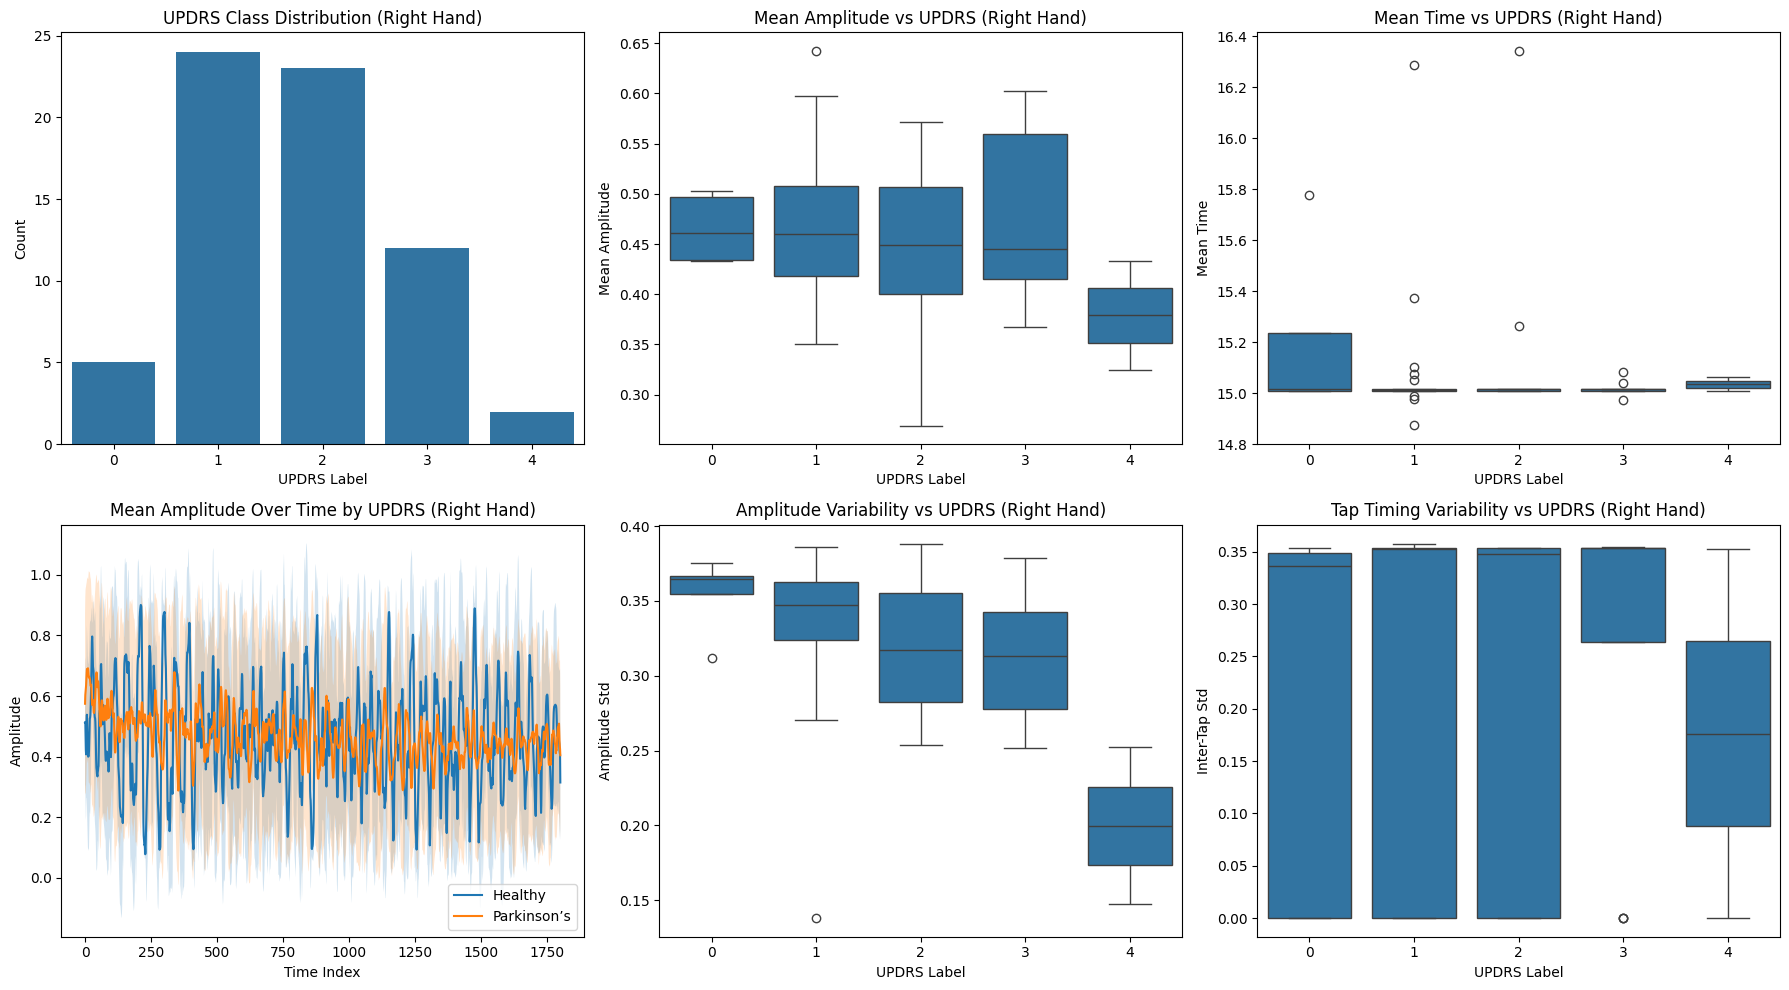

In [14]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# -------------------------------
# 1. UPDRS Class Distribution
# -------------------------------
sns.countplot(x="updrs_right", data=right_df, ax=ax[0, 0])
ax[0, 0].set_title("UPDRS Class Distribution (Right Hand)")
ax[0, 0].set_xlabel("UPDRS Label")
ax[0, 0].set_ylabel("Count")

# -------------------------------
# 2. Mean Amplitude vs UPDRS
# -------------------------------
right_amp_means = right_df["amplitude"].apply(np.mean)
sns.boxplot(x=right_df["updrs_right"], y=right_amp_means, ax=ax[0, 1])
ax[0, 1].set_title("Mean Amplitude vs UPDRS (Right Hand)")
ax[0, 1].set_xlabel("UPDRS Label")
ax[0, 1].set_ylabel("Mean Amplitude")

# -------------------------------
# 3. Mean Time vs UPDRS
# -------------------------------
right_time_means = right_df["time"].apply(np.mean)
sns.boxplot(x=right_df["updrs_right"], y=right_time_means, ax=ax[0, 2])
ax[0, 2].set_title("Mean Time vs UPDRS (Right Hand)")
ax[0, 2].set_xlabel("UPDRS Label")
ax[0, 2].set_ylabel("Mean Time")

# -------------------------------
# 4. Amplitude over Time by UPDRS
# -------------------------------
amp_0 = np.stack(right_df[right_df["updrs_right"] == 0]["amplitude"].values)
amp_1 = np.stack(right_df[right_df["updrs_right"] == 1]["amplitude"].values)

mean_0, std_0 = amp_0.mean(axis=0), amp_0.std(axis=0)
mean_1, std_1 = amp_1.mean(axis=0), amp_1.std(axis=0)

time_axis = np.arange(len(mean_0))

ax[1, 0].plot(time_axis, mean_0, label="Healthy")
ax[1, 0].fill_between(time_axis, mean_0 - std_0, mean_0 + std_0, alpha=0.2)

ax[1, 0].plot(time_axis, mean_1, label="Parkinson’s")
ax[1, 0].fill_between(time_axis, mean_1 - std_1, mean_1 + std_1, alpha=0.2)

ax[1, 0].set_title("Mean Amplitude Over Time by UPDRS (Right Hand)")
ax[1, 0].set_xlabel("Time Index")
ax[1, 0].set_ylabel("Amplitude")
ax[1, 0].legend()

# -------------------------------
# 5. Amplitude Variability vs UPDRS
# -------------------------------
right_df["amp_std"] = right_df["amplitude"].apply(np.std)
sns.boxplot(x="updrs_right", y="amp_std", data=right_df, ax=ax[1, 1])
ax[1, 1].set_title("Amplitude Variability vs UPDRS (Right Hand)")
ax[1, 1].set_xlabel("UPDRS Label")
ax[1, 1].set_ylabel("Amplitude Std")

# -------------------------------
# 6. Tap Timing Variability vs UPDRS
# -------------------------------
def inter_tap_std(time_seq):
    return np.std(np.diff(np.array(time_seq)))

right_df["tap_interval_std"] = right_df["time"].apply(inter_tap_std)
sns.boxplot(x="updrs_right", y="tap_interval_std", data=right_df, ax=ax[1, 2])
ax[1, 2].set_title("Tap Timing Variability vs UPDRS (Right Hand)")
ax[1, 2].set_xlabel("UPDRS Label")
ax[1, 2].set_ylabel("Inter-Tap Std")

plt.tight_layout()
plt.show()


**🔄 Comparative Exploratory Data Analysis.**



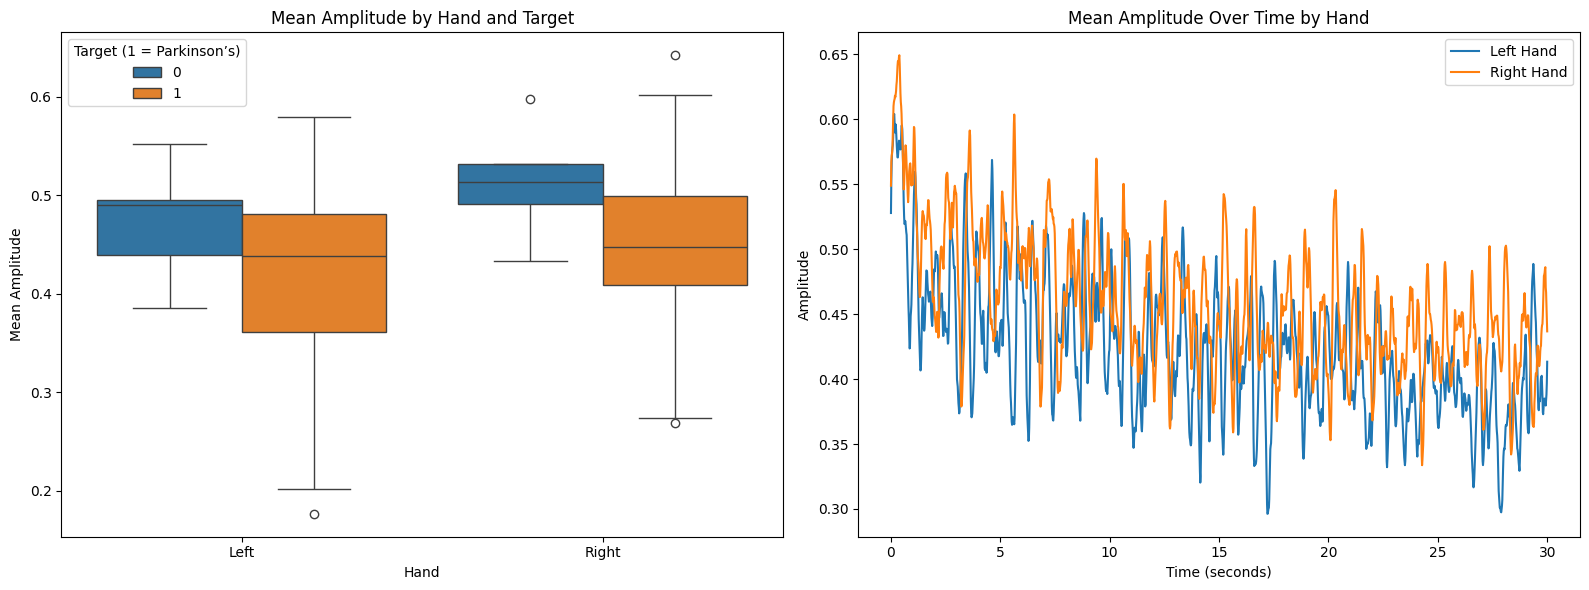

In [15]:

# ---------- Prepare data ----------
left_df = left_df.copy()
right_df = right_df.copy()

left_df["hand"] = "Left"
right_df["hand"] = "Right"

# Mean amplitude per patient
left_df["mean_amplitude"] = left_df["amplitude"].apply(np.mean)
right_df["mean_amplitude"] = right_df["amplitude"].apply(np.mean)

combined_df = pd.concat([left_df, right_df], ignore_index=True)

# ---------- Mean amplitude over time ----------
def mean_amplitude_over_time(df):
    # stack padded signals: (n_patients, 1800)
    stacked = np.vstack(df["amplitude"].values)
    return np.mean(stacked, axis=0)

left_mean_curve = mean_amplitude_over_time(left_df)
right_mean_curve = mean_amplitude_over_time(right_df)

# Time axis (ends at 30s as you observed)
time_axis = np.linspace(0, 30, len(left_mean_curve))

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) Mean amplitude by hand and target
sns.boxplot(
    data=combined_df,
    x="hand",
    y="mean_amplitude",
    hue="target",
    ax=axes[0]
)
axes[0].set_title("Mean Amplitude by Hand and Target")
axes[0].set_xlabel("Hand")
axes[0].set_ylabel("Mean Amplitude")
axes[0].legend(title="Target (1 = Parkinson’s)")

# (2) Mean amplitude over time by hand
axes[1].plot(time_axis, left_mean_curve, label="Left Hand")
axes[1].plot(time_axis, right_mean_curve, label="Right Hand")
axes[1].set_title("Mean Amplitude Over Time by Hand")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature Engineering


In [16]:
# Cell 1 — Load + parse data (binary labels already encoded)
LEFT_CSV_PATH  = "dataset/processed/left.csv"
RIGHT_CSV_PATH = "dataset/processed/right.csv"

left_df = pd.read_csv(LEFT_CSV_PATH)
right_df = pd.read_csv(RIGHT_CSV_PATH)

def _ensure_list(x):
    """
    CSV saves lists as strings, e.g. "[0.1, 0.2, ...]".
    Convert string -> Python list safely.
    """
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return list(x)

for df in [left_df, right_df]:
    df["amplitude"] = df["amplitude"].apply(_ensure_list)
    df["time"] = df["time"].apply(_ensure_list)


# Quick dataset sanity checks
def summarize_lengths(df, name):
    amp_lens = df["amplitude"].apply(len)
    time_lens = df["time"].apply(len)
    print(f"\n{name} — rows: {len(df)}")
    print("Amplitude length summary:\n", amp_lens.describe())
    print("Time length summary:\n", time_lens.describe())

summarize_lengths(left_df, "LEFT")
summarize_lengths(right_df, "RIGHT")

print("\nClass balance (binary labels from rating sheet):")
print("LEFT target counts:\n", left_df["target"].value_counts())
print("RIGHT target counts:\n", right_df["target"].value_counts())




LEFT — rows: 66
Amplitude length summary:
 count      66.0
mean     1800.0
std         0.0
min      1800.0
25%      1800.0
50%      1800.0
75%      1800.0
max      1800.0
Name: amplitude, dtype: float64
Time length summary:
 count      66.0
mean     1800.0
std         0.0
min      1800.0
25%      1800.0
50%      1800.0
75%      1800.0
max      1800.0
Name: time, dtype: float64

RIGHT — rows: 66
Amplitude length summary:
 count      66.0
mean     1800.0
std         0.0
min      1800.0
25%      1800.0
50%      1800.0
75%      1800.0
max      1800.0
Name: amplitude, dtype: float64
Time length summary:
 count      66.0
mean     1800.0
std         0.0
min      1800.0
25%      1800.0
50%      1800.0
75%      1800.0
max      1800.0
Name: time, dtype: float64

Class balance (binary labels from rating sheet):
LEFT target counts:
 target
1    61
0     5
Name: count, dtype: int64
RIGHT target counts:
 target
1    61
0     5
Name: count, dtype: int64


In [17]:
# Signal preprocessing

def preprocess_signal(
    amplitude,
    window_length=7,
    polyorder=2,
    apply_filter=True
):
    """
    Light preprocessing for finger tapping amplitude signals.

    Parameters:
    - amplitude: list or np.array of raw amplitude values
    - window_length: Savitzky–Golay window (must be odd)
    - polyorder: polynomial order for smoothing
    - apply_filter: whether to apply smoothing

    Returns:
    - processed_amplitude: np.array
    """
    amplitude = np.asarray(amplitude, dtype=float)

    if apply_filter:
        # Safety: window must be < signal length and odd
        if window_length >= len(amplitude):
            window_length = len(amplitude) - 1
        if window_length % 2 == 0:
            window_length += 1

        amplitude = savgol_filter(
            amplitude,
            window_length=window_length,
            polyorder=polyorder
        )

    return amplitude


In [18]:
# Checking results of singal processing

raw = left_df.loc[0, "amplitude"]
filtered = preprocess_signal(raw)

print("Raw first 10:", raw[:10])
print("Filtered first 10:", filtered[:10])


Raw first 10: [0.851907050083096, 0.8627108573966841, 0.867190948619356, 0.8572750141690726, 0.8542504247747521, 0.8591989244544896, 0.8647101402066645, 0.8575911139038013, 0.8498909628069391, 0.8501318577070844]
Filtered first 10: [0.85701459 0.8582887  0.85931667 0.86009849 0.85874743 0.8589805
 0.85958674 0.85721893 0.85342848 0.85182627]


In [19]:
# Robust peak detection (ignores padded time issues)

def extract_peaks(
    amplitude,
    time,
    prominence_ratio=0.1,
    min_interval_sec=0.15,
    fallback_duration_sec=30.0
):
    """
    Adaptive peak detection, robust to time arrays that have repeated values
    (e.g., padding). Uses inferred dt from time if valid; otherwise falls back
    to duration/len(amplitude).
    """
    amplitude = np.asarray(amplitude, dtype=float)
    time = np.asarray(time, dtype=float)

    # Try to infer dt from time, but guard against duplicates/padding
    diffs = np.diff(time)
    diffs = diffs[diffs > 0]  # keep only strictly positive steps

    if len(diffs) > 0:
        dt = np.median(diffs)
    else:
        # Fallback: assume fixed duration across 1800 samples
        dt = fallback_duration_sec / len(amplitude)

    # Convert min interval to samples; clamp to at least 1
    min_distance_samples = max(1, int(min_interval_sec / dt))

    # Adaptive prominence
    signal_range = np.max(amplitude) - np.min(amplitude)
    prominence = prominence_ratio * signal_range

    peaks, properties = find_peaks(
        amplitude,
        prominence=prominence,
        distance=min_distance_samples
    )

    peak_amplitudes = amplitude[peaks]
    peak_times = time[peaks]  # OK even if time has repeats; we handle ITIs later safely

    return peaks, peak_amplitudes, peak_times


In [20]:
# Checking the results of peak detection

idx = 0  # try a few different indices later
amp = preprocess_signal(left_df.loc[idx, "amplitude"])
t = np.array(left_df.loc[idx, "time"])

peaks, peak_amps, peak_times = extract_peaks(amp, t)

print("Number of taps detected:", len(peaks))
print("First 5 peak amplitudes:", peak_amps[:5])
print("First 5 ITIs:", np.diff(peak_times)[:5])


Number of taps detected: 52
First 5 peak amplitudes: [0.88315335 0.90156563 0.98487479 0.87578559 0.98893613]
First 5 ITIs: [0.66666667 0.53333333 0.78333333 0.61666667 0.65      ]


In [21]:
# Robust feature extraction (ITI from indices if needed)

def extract_features_from_signal(
    amplitude,
    time,
    early_frac=0.2,
    min_early_peaks=3,
    fallback_duration_sec=30.0
):
    amp = preprocess_signal(amplitude)
    t = np.asarray(time, dtype=float)

    peaks, peak_amps, peak_times = extract_peaks(amp, t, fallback_duration_sec=fallback_duration_sec)

    if len(peak_amps) < 5:
        return {
            "num_taps": np.nan,
            "mean_peak_amp": np.nan,
            "std_peak_amp": np.nan,
            "amp_decrement": np.nan,
            "mean_iti": np.nan,
            "std_iti": np.nan,
            "cv_iti": np.nan,
            "num_long_pauses": np.nan,
            "prop_long_pauses": np.nan,
        }

    features = {}
    features["num_taps"] = len(peak_amps)

    features["mean_peak_amp"] = np.mean(peak_amps)
    features["std_peak_amp"] = np.std(peak_amps)

    n_early = max(min_early_peaks, int(early_frac * len(peak_amps)))
    early_mean = np.mean(peak_amps[:n_early])
    late_mean = np.mean(peak_amps[-n_early:])
    features["amp_decrement"] = early_mean - late_mean

    # Robust dt inference
    diffs = np.diff(t)
    diffs = diffs[diffs > 0]
    if len(diffs) > 0:
        dt = np.median(diffs)
    else:
        dt = fallback_duration_sec / len(amp)

    # ITI from peak index differences (more reliable than time if time has repeats)
    peak_index_diffs = np.diff(peaks)
    itis = peak_index_diffs * dt

    features["mean_iti"] = np.mean(itis)
    features["std_iti"] = np.std(itis)
    features["cv_iti"] = features["std_iti"] / features["mean_iti"] if features["mean_iti"] > 0 else np.nan

    median_iti = np.median(itis)
    long_pauses = itis > (1.5 * median_iti)
    features["num_long_pauses"] = int(np.sum(long_pauses))
    features["prop_long_pauses"] = float(np.mean(long_pauses))

    return features


In [22]:
# Checking the results of feature extraction

feat_test = extract_features_from_signal(
    left_df.loc[0, "amplitude"],
    left_df.loc[0, "time"]
)

feat_test


{'num_taps': 52,
 'mean_peak_amp': np.float64(0.8958470621937895),
 'std_peak_amp': np.float64(0.04354757888265327),
 'amp_decrement': np.float64(0.05518877314979864),
 'mean_iti': np.float64(0.5421568627450961),
 'std_iti': np.float64(0.05980660017573532),
 'cv_iti': np.float64(0.11031235475452122),
 'num_long_pauses': 0,
 'prop_long_pauses': 0.0}

In [23]:
# Cell 5 — Build feature tables (binary labels already encoded)

def build_feature_table(df, hand="left"):
    """
    Build a feature table from a dataframe containing
    amplitude, time, updrs_left/updrs_right and target columns.
    """
    feature_rows = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Extracting {hand} features"):
        features = extract_features_from_signal(
            row["amplitude"],
            row["time"]
        )

        # Attach identifiers and labels
        features["patient_id"] = row["patient_id"]
        features["hand"] = hand

        if hand == "left":
            features["updrs"] = int(row["updrs_left"])   # binary label from rating sheet
            features["target"] = int(row["target"])
        else:
            features["updrs"] = int(row["updrs_right"])  # binary label from rating sheet
            features["target"] = int(row["target"])

        feature_rows.append(features)

    return pd.DataFrame(feature_rows)

# Build feature tables
left_features_df = build_feature_table(left_df, hand="left")
right_features_df = build_feature_table(right_df, hand="right")

# Sanity checks
print("LEFT features shape:", left_features_df.shape)
print("RIGHT features shape:", right_features_df.shape)

print("\nLEFT feature-table class balance:")
print(left_features_df["target"].value_counts())

print("\nRIGHT feature-table class balance:")
print(right_features_df["target"].value_counts())

left_features_df.tail(15)


Extracting right features: 100%|██████████| 66/66 [00:00<00:00, 712.92it/s]


LEFT features shape: (66, 13)
RIGHT features shape: (66, 13)

LEFT feature-table class balance:
target
1    61
0     5
Name: count, dtype: int64

RIGHT feature-table class balance:
target
1    61
0     5
Name: count, dtype: int64


,num_taps,mean_peak_amp,std_peak_amp,amp_decrement,mean_iti,std_iti,cv_iti,num_long_pauses,prop_long_pauses,patient_id,hand,updrs,target
51,18,0.824225,0.184931,-0.196232,1.624510,1.253598,0.771678,8,0.470588,PD50,left,4,1
52,61,0.943668,0.064620,0.088273,0.490556,0.085817,0.174938,0,0.000000,PD51,left,1,1
53,86,0.791562,0.135128,0.202981,0.348431,0.047460,0.136210,0,0.000000,PD52,left,2,1
54,18,0.911240,0.043094,0.091264,1.616667,0.241861,0.149605,0,0.000000,PD53,left,2,1
55,60,0.707200,0.235543,0.401297,0.499153,0.125115,0.250654,3,0.050847,PD54,left,3,1
56,52,0.710430,0.196844,0.269572,0.576144,0.129783,0.225262,1,0.019608,PD55,left,3,1
57,42,0.793319,0.081555,0.156487,0.704065,0.048246,0.068525,0,0.000000,PD56,left,2,1
58,26,0.734888,0.071131,0.034294,1.146667,0.147949,0.129025,0,0.000000,PD57,left,2,1
59,39,0.948916,0.026259,0.023458,0.752193,0.090173,0.119880,0,0.000000,PD58,left,1,1
60,84,0.528788,0.193812,0.418510,0.352811,0.085994,0.243741,0,0.000000,PD59,left,3,1


In [24]:
# Find rows where time has duplicate steps / padding artifacts

'''This diagnostic identifies recordings where the time vector is not strictly increasing due to padding with repeated end values (e.g. 30.0s).
These signals are not corrupted; padding occurs after the movement window.
Feature extraction therefore avoids relying on raw time differences and instead uses robust index-based timing.'''

def time_has_issues(t):
    t = np.asarray(t, dtype=float)
    return np.any(np.diff(t) <= 0)

bad_left = left_df[left_df["time"].apply(time_has_issues)]
bad_right = right_df[right_df["time"].apply(time_has_issues)]

print("Bad LEFT rows:", len(bad_left))
print("Bad RIGHT rows:", len(bad_right))


Bad LEFT rows: 46
Bad RIGHT rows: 42


C:\Users\bubut\AppData\Local\Temp\ipykernel_26540\1411552443.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Healthy (UPDRS 0–1)", "PD (UPDRS 2–4)"])
C:\Users\bubut\AppData\Local\Temp\ipykernel_26540\1411552443.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Healthy (UPDRS 0–1)", "PD (UPDRS 2–4)"])
C:\Users\bubut\AppData\Local\Temp\ipykernel_26540\1411552443.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Healthy (UPDRS 0–1)", "PD (UPDRS 2–4)"])
C:\Users\bubut\AppData\Local\Temp\ipykernel_26540\1411552443.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["H

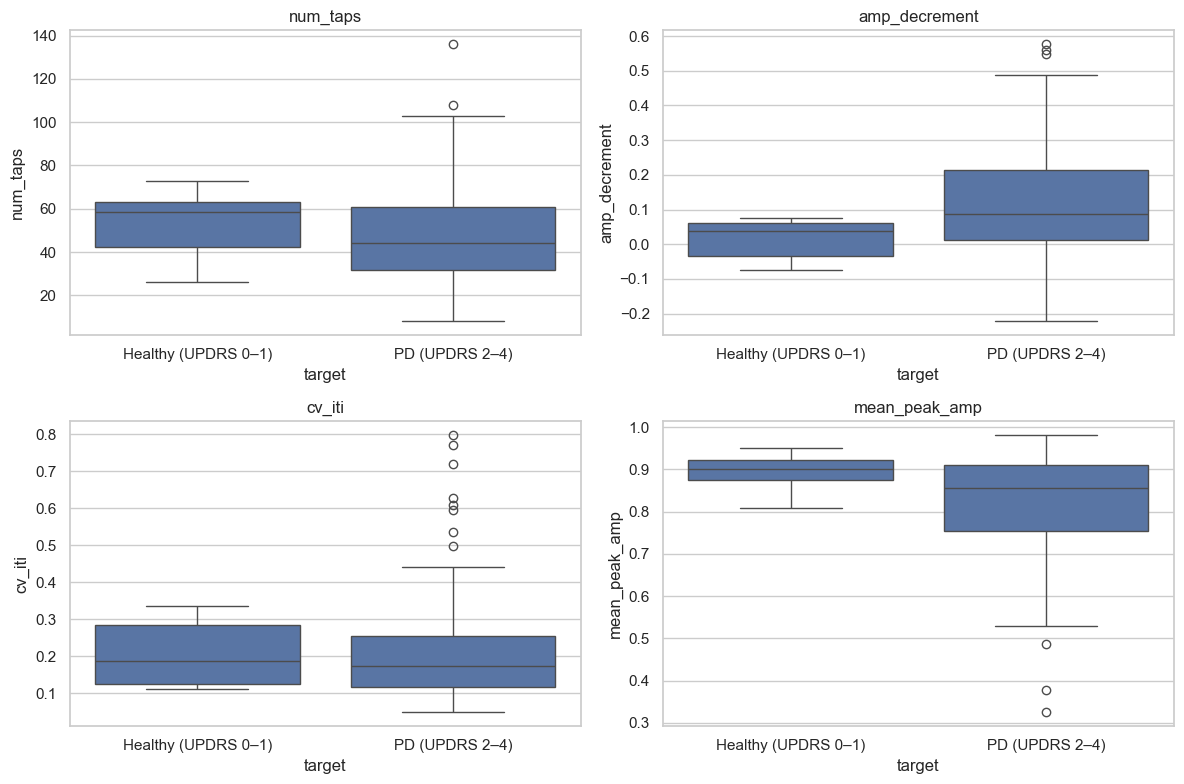

In [25]:
# FIXED validation plots (ensure both classes show)

features_df = pd.concat([left_features_df, right_features_df], ignore_index=True)

# Make sure target is numeric
features_df["target"] = features_df["target"].astype(int)

key_features = ["num_taps", "amp_decrement", "cv_iti", "mean_peak_amp"]

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, key_features):
    sns.boxplot(
        data=features_df,
        x="target",
        y=feature,
        ax=ax
    )
    ax.set_xticklabels(["Healthy (UPDRS 0–1)", "PD (UPDRS 2–4)"])
    ax.set_title(feature)

plt.tight_layout()
plt.show()


In [26]:
### UPDRS Compression

In [27]:
# Reduce the UPDRS Scores from 0 to 4 to 0, 1 = 0, 2, 3 = 1, 4 = 2

left_features_df['updrs'] = left_features_df['updrs'].apply(lambda x: 0 if x == 0 or x == 1 else (1 if x == 2 or x == 3 else 2))
right_features_df['updrs'] = right_features_df['updrs'].apply(lambda x: 0 if x == 0 or x == 1 else (1 if x == 2 or x == 3 else 2))

In [28]:
right_features_df.head(20)

,num_taps,mean_peak_amp,std_peak_amp,amp_decrement,mean_iti,std_iti,cv_iti,num_long_pauses,prop_long_pauses,patient_id,hand,updrs,target
0,61,0.914892,0.047774,0.075582,0.467500,0.057205,0.122364,0,0.000000,C34,right,0,0
1,73,0.844620,0.148506,-0.074605,0.377778,0.105299,0.278734,4,0.055556,C35,right,0,0
2,60,0.951034,0.019800,0.014383,0.487006,0.054812,0.112550,0,0.000000,C36,right,0,0
3,26,0.934253,0.028889,0.023459,1.145333,0.244746,0.213689,1,0.040000,C37,right,0,0
4,36,0.925534,0.032226,-0.072683,0.778095,0.234648,0.301568,1,0.028571,C38,right,0,0
5,48,0.912416,0.060241,0.008989,0.631560,0.046028,0.072880,0,0.000000,PD0,right,0,1
6,12,0.936915,0.036947,0.072220,2.368182,0.952865,0.402362,0,0.000000,PD1,right,1,1
7,44,0.804921,0.117572,0.310629,0.643798,0.056836,0.088282,0,0.000000,PD10,right,1,1
8,8,0.980912,0.013245,0.026483,3.166667,0.406300,0.128305,0,0.000000,PD11,right,1,1
9,53,0.775437,0.101320,0.244272,0.544231,0.093077,0.171025,0,0.000000,PD12,right,0,1


In [29]:
# Export feature tables to CSV (for modelling)


LEFT_OUT_PATH  = "dataset/processed/left_hand_features.csv"
RIGHT_OUT_PATH = "dataset/processed/right_hand_features.csv"

left_features_df.to_csv(LEFT_OUT_PATH, index=False)
right_features_df.to_csv(RIGHT_OUT_PATH, index=False)

print("Saved feature tables:")
print(" -", LEFT_OUT_PATH)
print(" -", RIGHT_OUT_PATH)

Saved feature tables:
 - dataset/processed/left_hand_features.csv
 - dataset/processed/right_hand_features.csv
